# Project on Fintech_Data_Analysis'

Problem Statement:

* Analyze fintech transaction data to identify patterns, inefficiencies, and support better decision-making.

Business Objectives:

* Reduce unnecessary or irregular spending patterns
* Analyze transaction trends to identify peak periods
* Detect high-value or unusual transactions
* Improve financial decision-making using data insights

# Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'/Users/aditisasankar/Downloads/bank_transactions_data_2.csv')

In [3]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [4]:
df.shape

(2512, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance           2512 non-n

In [6]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [7]:
df.index

RangeIndex(start=0, stop=2512, step=1)

In [8]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='str')

In [9]:
df.dtypes

TransactionID                  str
AccountID                      str
TransactionAmount          float64
TransactionDate                str
TransactionType                str
Location                       str
DeviceID                       str
IP Address                     str
MerchantID                     str
Channel                        str
CustomerAge                  int64
CustomerOccupation             str
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate        str
dtype: object

In [10]:
len(df)

2512

In [11]:
max(df.index)

2511

In [12]:
min(df.index)

0

# Data Cleaning

In [13]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [14]:
df.drop_duplicates()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [15]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [16]:
df['Month'] = df['TransactionDate'].dt.month

# Visualization

# Histogram for transaction amount

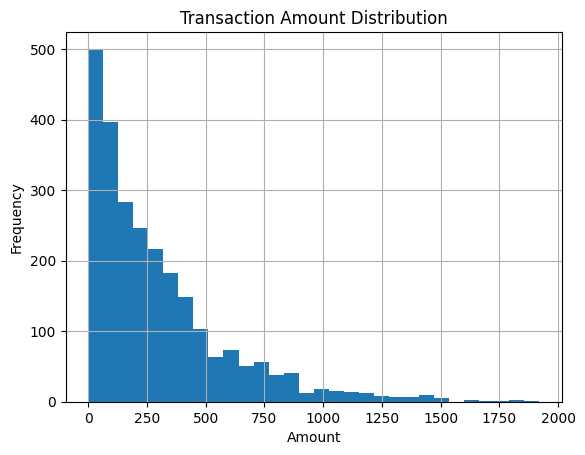

In [17]:
plt.figure()
df['TransactionAmount'].hist(bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Debit vs Credit Comparison

In [18]:
type_analysis = df.groupby('TransactionType')['TransactionAmount'].agg(['sum', 'mean', 'count'])
type_analysis

,sum,mean,count
TransactionType,,,
Credit,174092.57,306.501004,568
Debit,573463.00,294.991255,1944


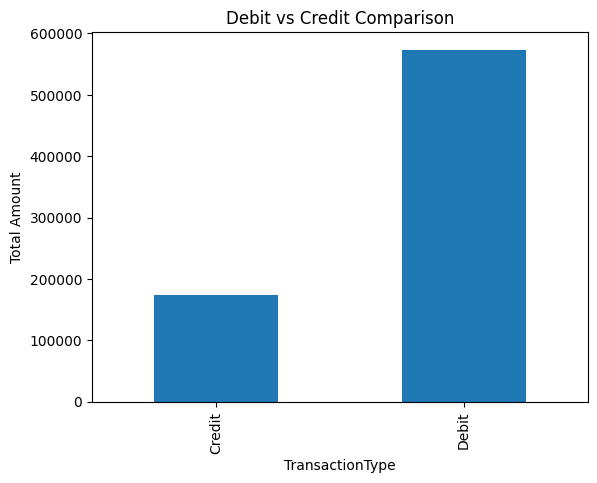

In [19]:
type_analysis['sum'].plot(kind='bar')
plt.title("Debit vs Credit Comparison")
plt.ylabel("Total Amount")
plt.show()

# Monthly Trend Analysis

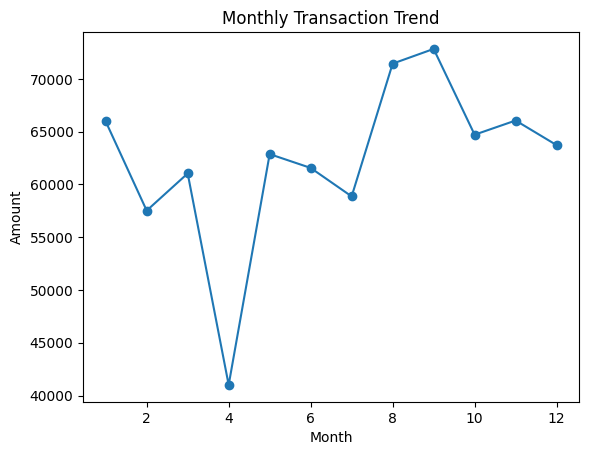

In [23]:
monthly = df.groupby('Month')['TransactionAmount'].sum()

monthly.plot(marker='o')
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

# KPI Creation

In [34]:
df.columns = df.columns.str.strip()

In [35]:
# Total transactions
total_transactions = df['TransactionID'].nunique()
total_transactions

2512

In [36]:
# Total Transactions
total_transactions = df['TransactionID'].nunique()
total_transactions

2512

In [37]:
# Average Transaction Amount
avg_transaction = df['TransactionAmount'].mean()
avg_transaction

np.float64(297.5937778662421)

In [39]:
# Total Customers
total_customers = df['AccountID'].nunique()
total_customers

495

In [40]:
# Transaction Volume
transaction_volume = df['TransactionID'].count()
transaction_volume

np.int64(2512)

In [41]:
df['Month'] = pd.to_datetime(df['TransactionDate']).dt.month
monthly_transactions = df.groupby('Month')['TransactionAmount'].sum()
monthly_transactions

Month
1     65964.34
2     57516.10
3     61036.12
4     41003.84
5     62868.01
6     61559.58
7     58861.39
8     71437.76
9     72832.25
10    64705.62
11    66051.13
12    63719.43
Name: TransactionAmount, dtype: float64